# Chapter 02 - Data Preprocessing
## Pre-Model Workflow and Data Preprocessing
Based on scikit-learn Cookbook. This notebook covers essential preprocessing steps before training machine learning models.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
plt.style.use('ggplot')

## 1. Load Dataset

In [2]:
wine = load_wine(as_frame=True)
X = wine.data.copy()
y = wine.target
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 2. Create Missing Values (Simulation)

In [3]:
np.random.seed(42)
X_missing = X.copy()
mask = np.random.rand(*X_missing.shape) < 0.05
X_missing[mask] = np.nan
X_missing.isna().sum().head()

,0
alcohol,8
malic_acid,10
ash,7
alcalinity_of_ash,10
magnesium,7


## 3. Missing Value Visualization

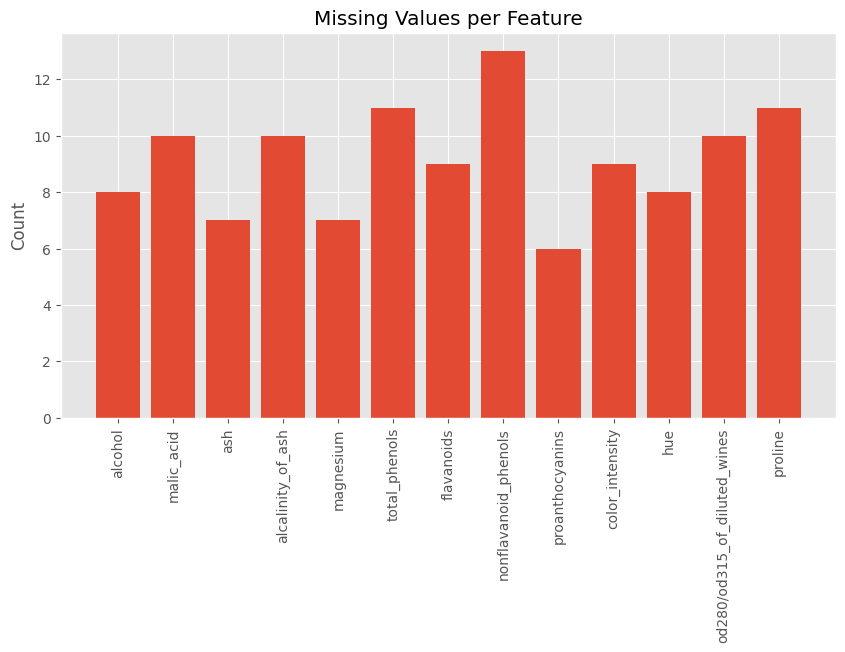

In [4]:
plt.figure(figsize=(10,5))
plt.bar(X_missing.columns, X_missing.isna().sum())
plt.xticks(rotation=90)
plt.title('Missing Values per Feature')
plt.ylabel('Count')
plt.show()

**Description:** This bar chart shows how many missing values exist in each feature. Missing values must be handled before model training.

## 4. Imputation using Mean Strategy

In [5]:
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X_missing), columns=X.columns)
X_imputed.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.600000,127.0,2.80,3.060000,0.28,2.29,5.64,0.956624,3.92,1065.0
1,13.20,1.78,2.14,11.200000,100.0,2.65,2.760000,0.26,1.28,4.38,1.050000,3.40,1050.0
2,13.16,2.36,2.67,19.474405,101.0,2.80,3.240000,0.30,2.81,5.68,1.030000,3.17,1185.0
3,14.37,1.95,2.50,19.474405,113.0,3.85,3.490000,0.24,2.18,7.80,0.860000,3.45,1480.0
4,13.24,2.59,2.87,21.000000,118.0,2.80,2.071775,0.39,1.82,4.32,1.040000,2.93,735.0


## 5. Feature Scaling Comparison

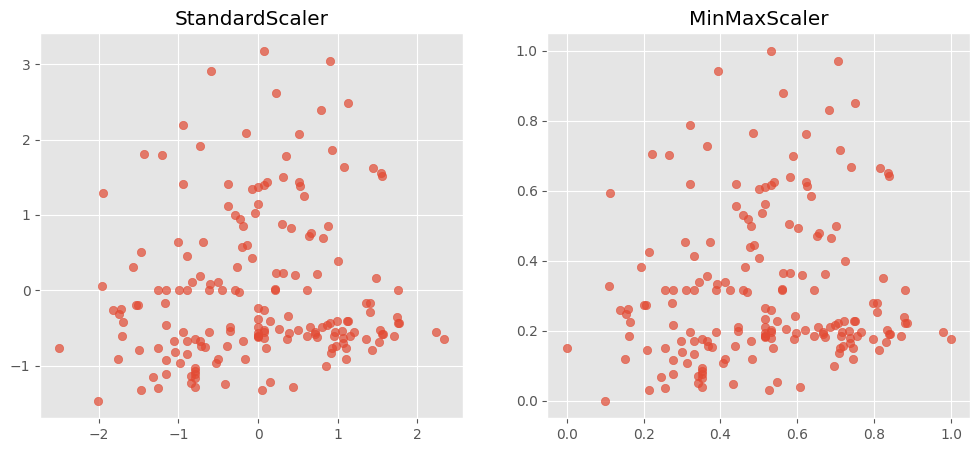

In [6]:
std_scaler = StandardScaler()
mm_scaler = MinMaxScaler()
std_data = std_scaler.fit_transform(X_imputed[['alcohol','malic_acid']])
mm_data = mm_scaler.fit_transform(X_imputed[['alcohol','malic_acid']])
fig, ax = plt.subplots(1,2, figsize=(12,5))
ax[0].scatter(std_data[:,0], std_data[:,1], alpha=0.7)
ax[0].set_title('StandardScaler')
ax[1].scatter(mm_data[:,0], mm_data[:,1], alpha=0.7)
ax[1].set_title('MinMaxScaler')
plt.show()

**Description:** StandardScaler centers data around mean=0 and std=1, while MinMaxScaler transforms values into range 0 to 1.

## 6. Pipeline Example

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X_missing, y, test_size=0.25, random_state=42, stratify=y)
pipe = Pipeline([('imputer', SimpleImputer(strategy='mean')), ('scaler', StandardScaler()), ('model', LogisticRegression(max_iter=1000))])
pipe.fit(X_train, y_train)
pred = pipe.predict(X_test)
print('Accuracy:', round(accuracy_score(y_test, pred),4))

Accuracy: 0.9556


## Important Concepts
- Missing Value Imputation
- Feature Scaling
- Data Leakage Prevention
- Pipeline Automation
- Consistent preprocessing for train/test data

## Summary
Data preprocessing is a critical step before modeling. Common tasks include handling missing values, scaling numeric features, and automating workflows with pipelines.